In [1]:
!pip install faker pandas numpy scikit-learn xgboost matplotlib scipy tqdm seaborn


[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


Generating realistic synthetic data...


100%|████████████████████████████████████████████████████████████████████████████| 5000/5000 [00:00<00:00, 8382.88it/s]



Training model...

Model Evaluation:
              precision    recall  f1-score   support

      Normal       0.97      0.87      0.92       903
      Threat       0.39      0.76      0.52        97

    accuracy                           0.86      1000
   macro avg       0.68      0.82      0.72      1000
weighted avg       0.92      0.86      0.88      1000

ROC-AUC: 0.9358


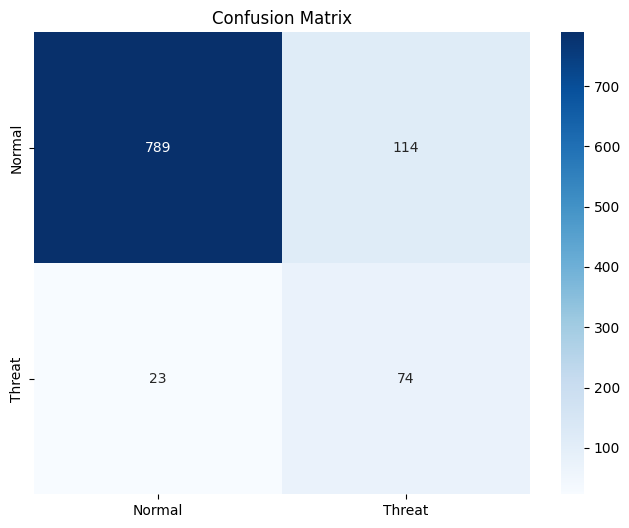

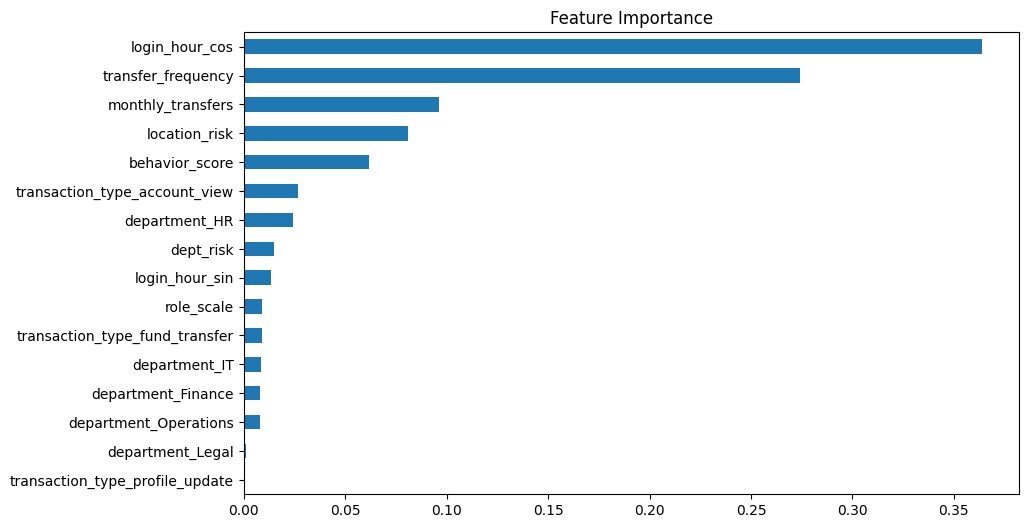


Suspicious Employees and Their Alerts:
Employee: c5371cb7-d82c-48e8-8004-222f4b7096bc
  Department: IT
  Role Scale: 4
  Alerts: ['Odd login time']
-------------------------------------------------
Employee: 7df07267-38bd-4dd3-8cc3-a47fed8fa13e
  Department: IT
  Role Scale: 3
  Alerts: ['Odd login time']
-------------------------------------------------
Employee: ddca1b66-ceea-4f77-886a-29083d54212c
  Department: IT
  Role Scale: 5
  Alerts: ['Odd login time', 'GenAI flag: Unauthorized data access', 'Frequent branch transfers']
-------------------------------------------------
Employee: 7e6813b4-b8c1-4dca-a4a3-0504f6de4884
  Department: Operations
  Role Scale: 2
  Alerts: ['Odd login time', 'Frequent branch transfers']
-------------------------------------------------
Employee: 39719202-f84d-433d-81a1-1871347f1095
  Department: Operations
  Role Scale: 5
  Alerts: ['Odd login time', 'GenAI flag: Unauthorized data access']
-------------------------------------------------
Employee: 4

In [2]:
# ---------------------
# 1) INSTALL DEPENDENCIES
# ---------------------
# Uncomment if needed in a Jupyter/Colab:
# !pip install faker pandas numpy scikit-learn xgboost matplotlib scipy tqdm seaborn

import pandas as pd
import numpy as np
from datetime import timedelta
from faker import Faker
from scipy.stats import entropy
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm

fake = Faker()
np.random.seed(42)

# ---------------------
# 2) DATA GENERATION WITH NEW COLUMNS
# ---------------------
def generate_realistic_data(num_entries=5000):
    """
    Generates synthetic employee data with extra columns:
      - role_scale: integer [1..5], 1 = highest privilege
      - branch: random branch assignment
      - device_ip: random IP address
      - monthly_transfers: times an employee changed branch in the last month
      - unauthorized_access_flag: simulated GenAI detection of unauthorized access
    """
    data = []
    print("Generating realistic synthetic data...")
    
    possible_branches = ["Mumbai", "Delhi", "Bangalore", "Chennai", "Kolkata",
                         "London", "New York", "Singapore", "Dubai"]
    
    for _ in tqdm(range(num_entries)):
        # Employee basics
        employee_id = fake.uuid4()
        department = np.random.choice(
            ["IT", "Finance", "Operations", "HR", "Legal"], 
            p=[0.3, 0.25, 0.25, 0.1, 0.1]
        )
        role_scale = np.random.randint(1, 6)  # 1 to 5
        branch = np.random.choice(possible_branches)
        
        # Normal Behavior Patterns
        login_time = fake.date_time_between("-180d", "now")
        
        # Typical transfer patterns (financial transactions)
        transfer_count = max(1, int(np.random.poisson(lam=1.5)))  # Usually 1-2
        
        # Threat Injection (10% base rate)
        is_threat = np.random.binomial(1, 0.1)
        
        if is_threat:
            # Force login time to odd hours
            odd_hours = [h for h in range(24) if not (6 <= h <= 18)]
            chosen_hour = np.random.choice(odd_hours)
            login_time = login_time.replace(hour=int(chosen_hour))
            
            # Elevated transfer count
            transfer_count += int(np.random.choice([1, 2], p=[0.7, 0.3]))
            
            # High-risk location 20% of the time
            if np.random.rand() < 0.2:
                location = np.random.choice(["RU", "CN", "IR"])
            else:
                location = fake.country_code()
        else:
            # 5% of "normal" also do something odd
            if np.random.rand() < 0.05:
                transfer_count += 1
                login_time = login_time.replace(hour=np.random.choice([22, 23, 0, 1, 2, 3]))
            location = fake.country_code()
        
        # Transaction Patterns (timestamps for each transaction)
        transfer_dates = sorted([
            fake.date_time_between(
                start_date=login_time - timedelta(days=np.random.randint(1, 30)),
                end_date=login_time
            ) for _ in range(transfer_count)
        ])
        
        # 15% chance for random transaction type
        if np.random.rand() < 0.15:
            transaction_type = np.random.choice(["fund_transfer", "account_view", "profile_update"])
        else:
            transaction_type = "account_view" if department == "Finance" else "profile_update"
        
        # Simulate unauthorized access detection by GenAI (5% for normal, 20% for threat)
        if is_threat and np.random.rand() < 0.2:
            unauthorized_access_flag = 1
        elif (not is_threat) and np.random.rand() < 0.05:
            unauthorized_access_flag = 1
        else:
            unauthorized_access_flag = 0
        
        # monthly_transfers: how many times employee changed branch in the last month
        # If they're a "threat," we might artificially increase
        if is_threat:
            monthly_transfers = np.random.choice([0,1,2,3], p=[0.3,0.3,0.3,0.1])
        else:
            monthly_transfers = np.random.choice([0,1,2,3], p=[0.6,0.3,0.09,0.01])
        
        # device_ip
        device_ip = fake.ipv4()
        
        data.append([
            employee_id, login_time, transaction_type, location, department, 
            transfer_dates, is_threat, role_scale, branch, device_ip, 
            monthly_transfers, unauthorized_access_flag
        ])
    
    cols = [
        "employee_id", "login_time", "transaction_type",
        "location", "department", "transfer_dates", "is_threat",
        "role_scale", "branch", "device_ip",
        "monthly_transfers", "unauthorized_access_flag"
    ]
    
    return pd.DataFrame(data, columns=cols)

# ---------------------
# 3) FEATURE ENGINEERING
# ---------------------
def prepare_features(data):
    """
    Creates additional numeric features:
      - login_hour_sin, login_hour_cos
      - transfer_count, transfer_frequency
      - location_risk, dept_risk
      - behavior_score
      - plus new columns for role_scale (1..5) and monthly_transfers
    """
    df = data.copy()
    
    # Time-based features
    df["login_hour_sin"] = np.sin(2 * np.pi * df["login_time"].dt.hour / 24)
    df["login_hour_cos"] = np.cos(2 * np.pi * df["login_time"].dt.hour / 24)
    
    # Transfer Patterns
    df["transfer_count"] = df["transfer_dates"].apply(len)
    df["transfer_frequency"] = df["transfer_dates"].apply(
        lambda x: len(x)/180 if len(x) > 0 else 0
    )
    
    # Location risk
    df["location_risk"] = df["location"].map({
        "RU": 0.8,
        "CN": 0.7,
        "IR": 0.9
    }).fillna(0.2)
    
    # Department risk
    risk_map = {"Finance": 0.6, "IT": 0.4, "Operations": 0.3, "HR": 0.2, "Legal": 0.5}
    df["dept_risk"] = df["department"].map(risk_map)
    
    # Composite behavior score
    df["behavior_score"] = (
        0.4 * df["transfer_frequency"] +
        0.3 * df["location_risk"] +
        0.3 * df["dept_risk"]
    )
    
    # Keep the new features in final data
    df["role_scale"] = df["role_scale"]          # 1..5
    df["monthly_transfers"] = df["monthly_transfers"]
    
    # Return final feature set (plus transaction_type/department for OHE)
    return df[[
        "transfer_frequency", "location_risk", "dept_risk", "behavior_score",
        "login_hour_sin", "login_hour_cos", "transaction_type", 
        "department", "role_scale", "monthly_transfers"
    ]]

# ---------------------
# 4) ALERT GENERATION
# ---------------------
def generate_alerts(data):
    """
    Scans each row for suspicious behavior and generates an array of alerts.
    Returns a DataFrame with an 'alerts' column (list of triggered alerts)
    and also returns a summary of suspicious employee IDs and their alerts.
    """
    df = data.copy()
    df["alerts"] = [[] for _ in range(len(df))]  # initialize empty list for each row
    
    # Let's define a simple set of suspicious device IPs for demonstration
    suspicious_ips = {"192.168.99.99", "10.10.10.10"}
    
    for i, row in df.iterrows():
        row_alerts = []
        
        # (1) Odd Login Time (outside 6..18)
        hour = row["login_time"].hour
        if hour < 6 or hour > 18:
            row_alerts.append("Odd login time")
        
        # (2) GenAI Unauthorized Access (if row["unauthorized_access_flag"] == 1)
        if row["unauthorized_access_flag"] == 1:
            row_alerts.append("GenAI flag: Unauthorized data access")
        
        # (3) Frequent Branch Transfers
        if row["monthly_transfers"] >= 2:
            row_alerts.append("Frequent branch transfers")
        
        # (4) Device IP check (toy example)
        ip = row["device_ip"]
        if ip in suspicious_ips:
            row_alerts.append("Suspicious IP address")
        # Alternatively, track IP changes over time, but that requires session-based approach
        
        # (5) Privilege abuse
        # Let's say a "fund_transfer" or "account_view" for a scale 5 is suspicious
        # or any "fund_transfer" for scale >= 4
        if row["role_scale"] >= 4 and row["transaction_type"] == "fund_transfer":
            row_alerts.append("Privilege abuse: role too low for fund transfers")
        
        # We can append more logic as needed ...
        
        df.at[i, "alerts"] = row_alerts
    
    # Collect suspicious IDs => any row that has at least 1 alert
    suspicious_df = df[df["alerts"].apply(lambda x: len(x) > 0)]
    
    # Summarize alerts by employee
    summary = {}
    for idx, row in suspicious_df.iterrows():
        emp_id = row["employee_id"]
        if emp_id not in summary:
            summary[emp_id] = {
                "department": row["department"],
                "role_scale": row["role_scale"],
                "alerts": []
            }
        summary[emp_id]["alerts"].extend(row["alerts"])
    
    return df, summary

# ---------------------
# 5) MAIN EXECUTION
# ---------------------
if __name__ == "__main__":
    # a) Generate Synthetic Data
    df = generate_realistic_data(num_entries=5000)
    
    # b) Prepare Features + Label
    feature_df = prepare_features(df)
    y = df["is_threat"]
    
    # c) Train/Test Split
    X_train, X_test, y_train, y_test = train_test_split(
        feature_df, y, test_size=0.2, stratify=y, random_state=42
    )
    
    # d) Build Preprocessing + Classifier Pipeline
    # We now have 2 new numeric features: role_scale, monthly_transfers
    # We'll treat 'role_scale', 'monthly_transfers' as numeric
    preprocessor = ColumnTransformer([
        ('num', StandardScaler(), [
            'transfer_frequency', 'location_risk', 'dept_risk', 'behavior_score',
            'login_hour_sin', 'login_hour_cos', 'role_scale', 'monthly_transfers'
        ]),
        ('cat', OneHotEncoder(handle_unknown='ignore'), [
            'transaction_type', 'department'
        ])
    ])
    
    model = Pipeline([
        ('preprocessor', preprocessor),
        ('classifier', XGBClassifier(
            scale_pos_weight=5,      # Handle class imbalance
            learning_rate=0.05,
            max_depth=3,
            subsample=0.8,
            colsample_bytree=0.8,
            eval_metric='aucpr',     # Good for imbalanced data
            random_state=42
        ))
    ])
    
    # e) Train the Model
    print("\nTraining model...")
    model.fit(X_train, y_train)
    
    # f) Evaluate the Model
    print("\nModel Evaluation:")
    y_pred = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]
    
    print(classification_report(y_test, y_pred, target_names=["Normal", "Threat"]))
    print(f"ROC-AUC: {roc_auc_score(y_test, y_proba):.4f}")
    
    # g) Confusion Matrix
    plt.figure(figsize=(8,6))
    sns.heatmap(
        confusion_matrix(y_test, y_pred),
        annot=True, fmt=',d', cmap='Blues',
        xticklabels=['Normal', 'Threat'],
        yticklabels=['Normal', 'Threat']
    )
    plt.title('Confusion Matrix')
    plt.show()
    
    # h) Feature Importance
    numeric_feats = [
        'transfer_frequency', 'location_risk', 'dept_risk', 'behavior_score',
        'login_hour_sin', 'login_hour_cos', 'role_scale', 'monthly_transfers'
    ]
    cat_feats = preprocessor.named_transformers_['cat'].get_feature_names_out(
        ['transaction_type', 'department']
    )
    feature_names = numeric_feats + list(cat_feats)
    
    importances = model.named_steps['classifier'].feature_importances_
    
    plt.figure(figsize=(10,6))
    pd.Series(importances, index=feature_names).sort_values().plot.barh()
    plt.title('Feature Importance')
    plt.show()
    
    # i) Generate Alerts
    # We run the 'generate_alerts' on the raw DataFrame 'df'
    # because it has columns like login_time, device_ip, role_scale, etc.
    alert_df, alert_summary = generate_alerts(df)
    
    # Print summary of suspicious employee IDs
    print("\nSuspicious Employees and Their Alerts:")
    for emp_id, info in alert_summary.items():
        print(f"Employee: {emp_id}")
        print(f"  Department: {info['department']}")
        print(f"  Role Scale: {info['role_scale']}")
        print(f"  Alerts: {list(set(info['alerts']))}")  # unique alerts
        print("-------------------------------------------------")
    

    suspicious_emp_ids = list(alert_summary.keys())
    print("\nList of Suspicious Employee IDs:")
    print(suspicious_emp_ids)
